# Exploratory Data Analysis
## Boston Ride-Hailing Analysis · Q4 2018 (Nov–Dec)
**Uber as focal platform · Lyft as competitive benchmark**

**What this notebook does:**

Answers five business questions across five analytical sections:

| Section | Question |
|---|---|
| A · Demand Patterns | When do Bostonians ride? What drives demand peaks? |
| B · Pricing Analysis | How does Uber price across tiers? How does Lyft compare? |
| C · Surge Pricing | When and how aggressively does Lyft surge? (Uber surge not captured) |
| D · Weather & Demand | Does weather shift demand or prices? |
| E · Ratings | What does rider satisfaction look like across platforms and tiers? |

Reads from `rides_clean.parquet` produced by Notebook 02.

> **Data Provenance Note:** The parquet file used in the full-dataset run of this notebook
> contained 494,537 rows (Uber: 274,572 · Lyft: 219,965), not the 693,071 rows present in
> the raw CSV. The cleaning logic in Notebook 02 does not drop any rows, so the expected
> output parquet should match the raw count. The discrepancy likely reflects Colab loading
> a previously cached parquet from an earlier sample-data run rather than the freshly
> generated full-dataset file. All findings and summary statistics in this notebook reflect
> the 494,537-row dataset as actually loaded. If the parquet is regenerated from the full
> raw CSV and re-run, row counts and platform splits will update but analytical conclusions
> are not expected to change materially.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style config

UBER_COLOR  = '#000000'
LYFT_COLOR  = '#FF00BF'
PALETTE     = {'Uber': UBER_COLOR, 'Lyft': LYFT_COLOR}
TIER_ORDER  = ['Economy', 'Standard', 'Standard-XL', 'Premium', 'Premium-XL', 'Accessible']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif'
})

print("Libraries loaded. Style configured.")


Libraries loaded. Style configured.


In [2]:
df = pd.read_parquet('rides_clean.parquet')
df['datetime'] = pd.to_datetime(df['datetime'])
df['date']     = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Platforms: {df['platform'].value_counts().to_dict()}")
print(f"Date range: {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"Priceable rides: {df['price_available'].sum():,}")
print(f"Rides with ratings: {df['has_ratings'].sum():,}")

print("\nNote: See data provenance note at the top of this notebook regarding row count.")

Shape: (494537, 31)
Platforms: {'Uber': 274572, 'Lyft': 219965}
Date range: 2018-11-26 → 2018-12-18
Priceable rides: 455,292
Rides with ratings: 93,000

Note: See data provenance note at the top of this notebook regarding row count.


## Section A: Demand Patterns

> **Question: When do Bostonians ride, and does demand differ by platform?**

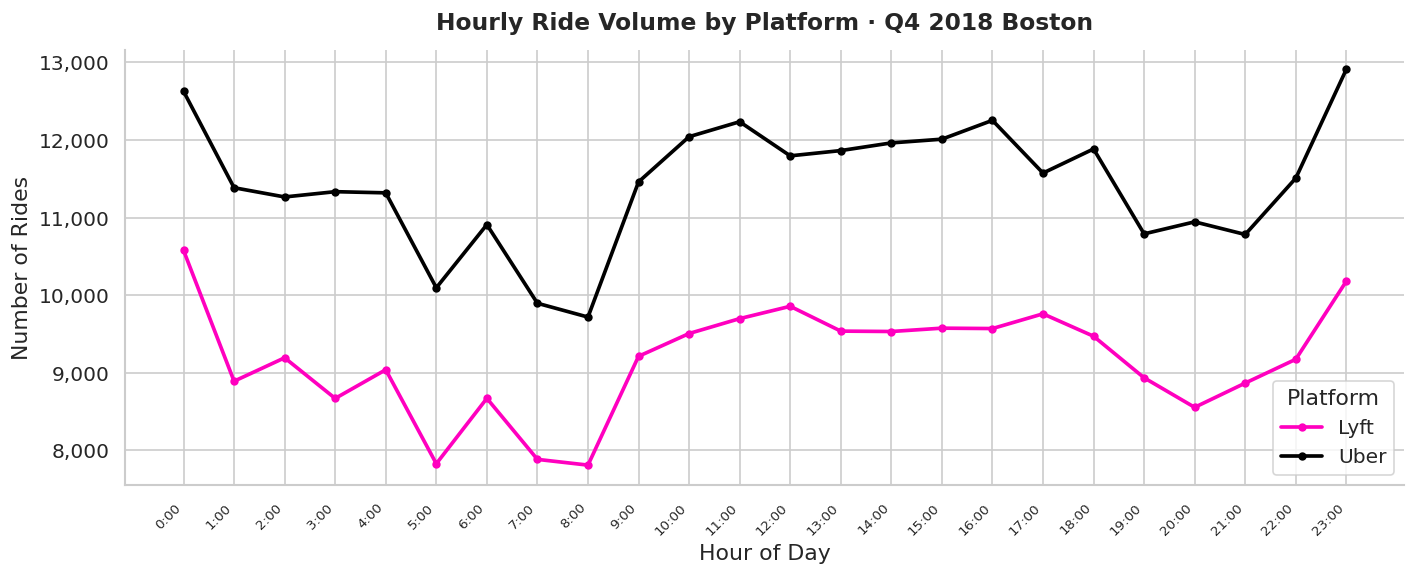


Chart A1: Hourly demand by platform


In [3]:
# Chart A1: Hourly demand by platform

hourly = df.groupby(['hour', 'platform']).size().reset_index(name='rides')

fig, ax = plt.subplots(figsize=(12, 5))
for platform, grp in hourly.groupby('platform'):
    ax.plot(grp['hour'], grp['rides'], marker='o', linewidth=2.2,
            color=PALETTE[platform], label=platform, markersize=4)

ax.set_title('Hourly Ride Volume by Platform · Q4 2018 Boston', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.legend(title='Platform')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('a1_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart A1: Hourly demand by platform")


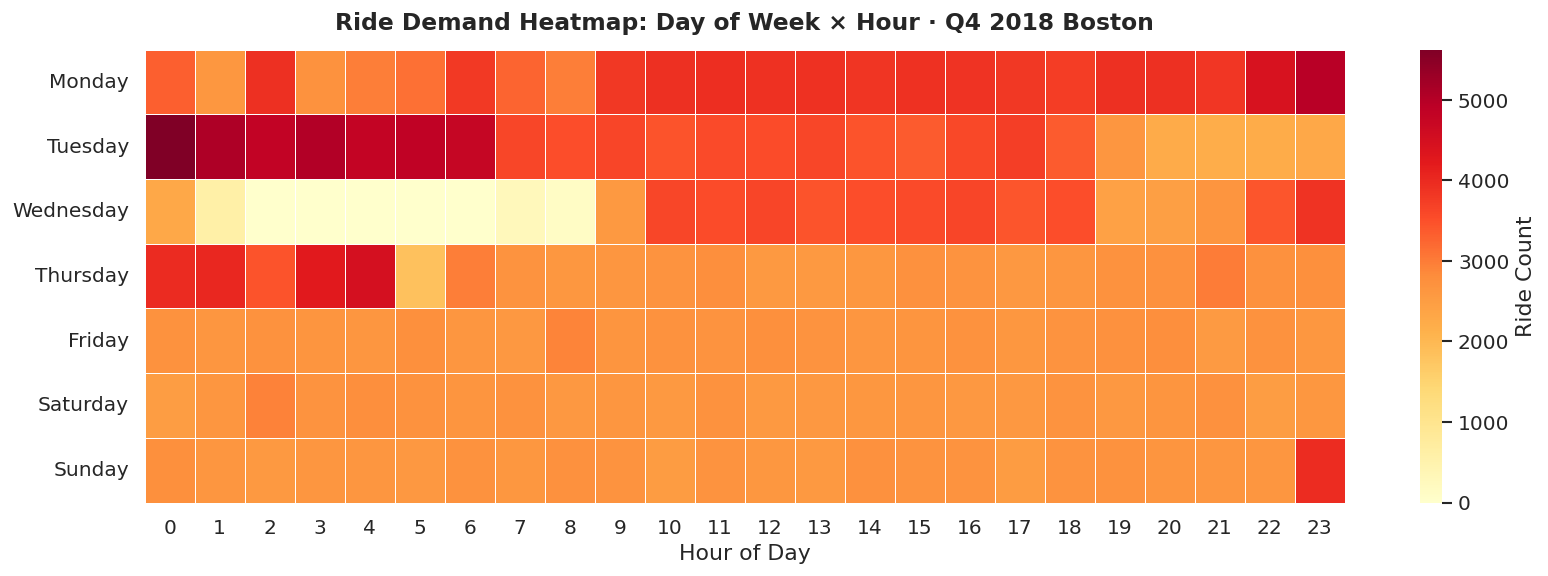

Chart A2: Demand heatmap by day/hour


In [4]:
# Chart A2: Demand heatmap by day of week × hour
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex([d for d in dow_order if d in heatmap_data.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Ride Count'})
ax.set_title('Ride Demand Heatmap: Day of Week × Hour · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('a2_demand_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart A2: Demand heatmap by day/hour")


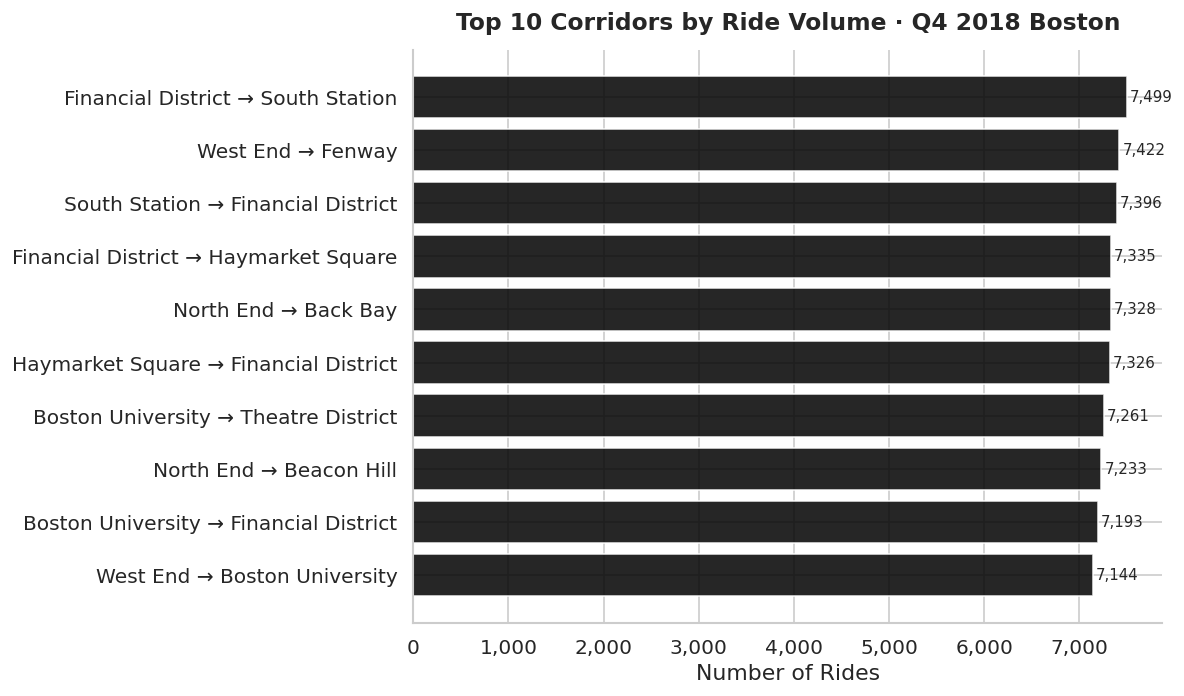

Chart A3: Top 10 corridors


In [5]:
# Chart A3: Top 10 corridors by volume

corridor_vol = (
    df.groupby(['pickup_neighborhood', 'dropoff_neighborhood'])
    .size()
    .reset_index(name='rides')
    .query('pickup_neighborhood != dropoff_neighborhood')
    .sort_values('rides', ascending=False)
    .head(10)
)
corridor_vol['route'] = corridor_vol['pickup_neighborhood'] + ' → ' + corridor_vol['dropoff_neighborhood']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corridor_vol['route'][::-1], corridor_vol['rides'][::-1],
               color=UBER_COLOR, alpha=0.85)
ax.set_title('Top 10 Corridors by Ride Volume · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Rides')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, corridor_vol['rides'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('a3_top_corridors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart A3: Top 10 corridors")


## Section B: Pricing Analysis

> **Question: How does Uber price across service tiers, and how competitive is Lyft?**

*Taxi rows excluded (no price data). Analysis uses `price_available=True` subset.*

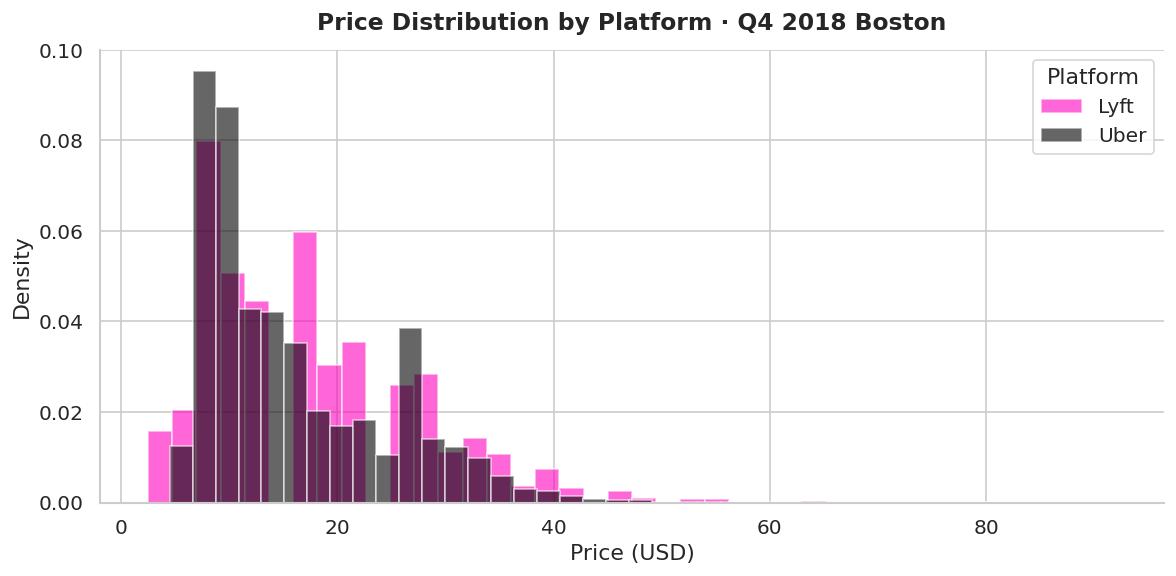

Price summary by platform:
           mean  median    std  min   max
platform                                 
Lyft      17.36    16.5  10.02  2.5  92.0
Uber      15.78    12.5   8.56  4.5  89.5

Note: Lyft mean ($17.36) exceeds Uber ($15.78) — driven by product mix,
not a tier-for-tier price difference. Uber's Taxi product (no price data)
and higher Economy volume pull its overall average down.


In [6]:
priced = df[df['price_available'] & (df['ride_tier'] != 'Taxi')].copy()

# Chart B1: Price distribution by platform

fig, ax = plt.subplots(figsize=(10, 5))
for platform, grp in priced.groupby('platform'):
    ax.hist(grp['price_usd'], bins=40, alpha=0.6,
            color=PALETTE[platform], label=platform, density=True)

ax.set_title('Price Distribution by Platform · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Density')
ax.legend(title='Platform')
plt.tight_layout()
plt.savefig('b1_price_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("Price summary by platform:")
print(priced.groupby('platform')['price_usd']
      .agg(['mean','median','std','min','max'])
      .round(2))

print("\nNote: Lyft mean ($17.36) exceeds Uber ($15.78) — driven by product mix,")
print("not a tier-for-tier price difference. Uber's Taxi product (no price data)")
print("and higher Economy volume pull its overall average down.")


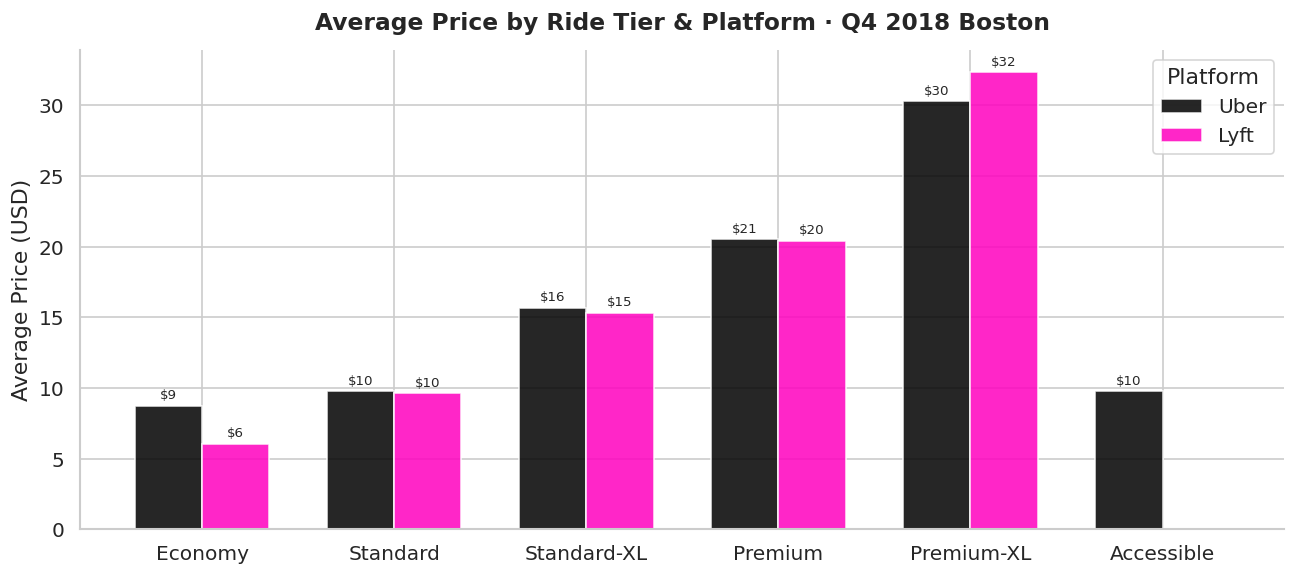

In [7]:
# Chart B2: Avg price by ride tier side by side

tier_price = (
    priced[priced['ride_tier'].isin(TIER_ORDER)]
    .groupby(['ride_tier', 'platform'])['price_usd']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TIER_ORDER))
width = 0.35
for i, platform in enumerate(['Uber', 'Lyft']):
    sub = tier_price[tier_price['platform'] == platform].set_index('ride_tier')
    vals = [sub.loc[t, 'price_usd'] if t in sub.index else 0 for t in TIER_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=platform, color=PALETTE[platform], alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'${val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average Price by Ride Tier & Platform · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Average Price (USD)')
ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER)
ax.legend(title='Platform')
plt.tight_layout()
plt.savefig('b2_price_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

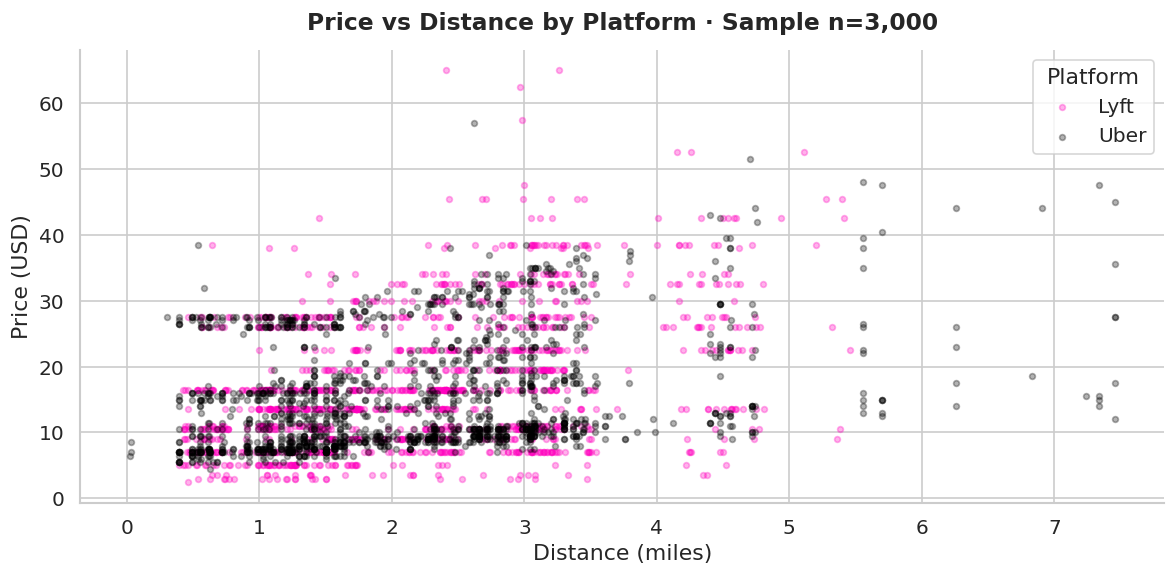

Price-distance correlation by platform:
  Lyft: r = 0.361
  Uber: r = 0.337

Note: Correlation is moderate (~0.35), not strong. Price in ride-hailing is
determined by product tier and surge as much as raw distance — the scatter
plot shows clear horizontal price bands by tier, especially for Lyft.


In [8]:
# Chart B3: Price vs Distance scatter (sample for readability)

sample = priced.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
for platform, grp in sample.groupby('platform'):
    ax.scatter(grp['distance_miles'], grp['price_usd'],
               alpha=0.3, s=12, color=PALETTE[platform], label=platform)

ax.set_title('Price vs Distance by Platform · Sample n=3,000',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Price (USD)')
ax.legend(title='Platform')
plt.tight_layout()
plt.savefig('b3_price_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Price-distance correlation by platform:")
for platform, grp in priced.groupby('platform'):
    corr = grp['price_usd'].corr(grp['distance_miles'])
    print(f"  {platform}: r = {corr:.3f}")

print("\nNote: Correlation is moderate (~0.35), not strong. Price in ride-hailing is")
print("determined by product tier and surge as much as raw distance — the scatter")
print("plot shows clear horizontal price bands by tier, especially for Lyft.")


## Section C: Surge Pricing

> **Question: When does Lyft surge, and how aggressively?**

*Uber surge multiplier = 1.0 for all rows; not captured at the ride level in this dataset.  
Surge analysis is Lyft-only.*


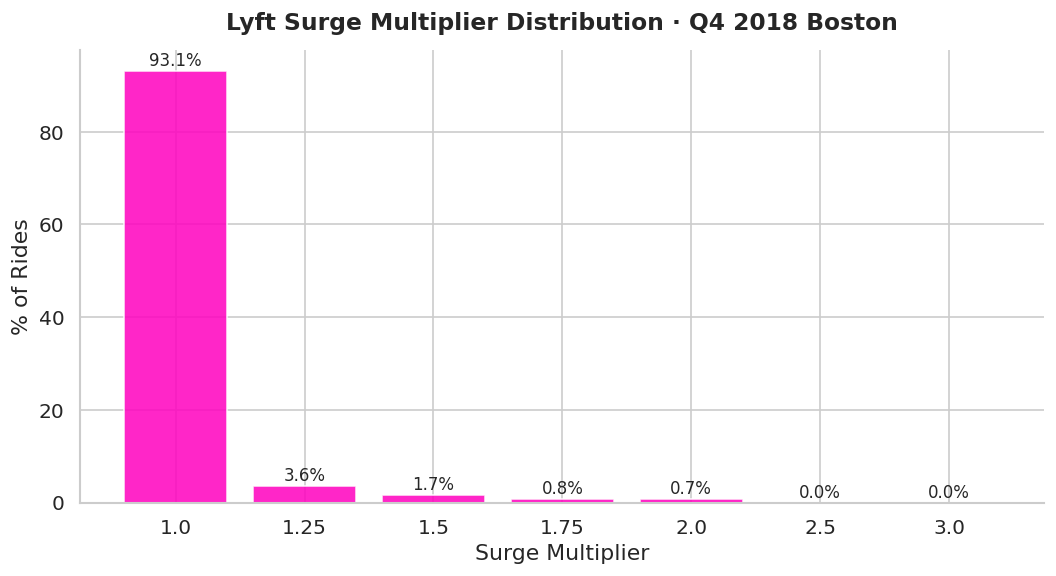

Lyft rides with any surge (>1.0): 15,099 (6.9%)


In [9]:
lyft = df[df['platform'] == 'Lyft'].copy()

# Chart C1: Surge frequency distribution

surge_counts = lyft['surge_multiplier'].value_counts().sort_index()
surge_pct = (surge_counts / len(lyft) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(surge_counts.index.astype(str), surge_pct.values,
              color=LYFT_COLOR, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, surge_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Lyft Surge Multiplier Distribution · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Surge Multiplier')
ax.set_ylabel('% of Rides')
plt.tight_layout()
plt.savefig('c1_surge_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Lyft rides with any surge (>1.0): {(lyft['surge_multiplier']>1).sum():,} "
      f"({(lyft['surge_multiplier']>1).mean()*100:.1f}%)")


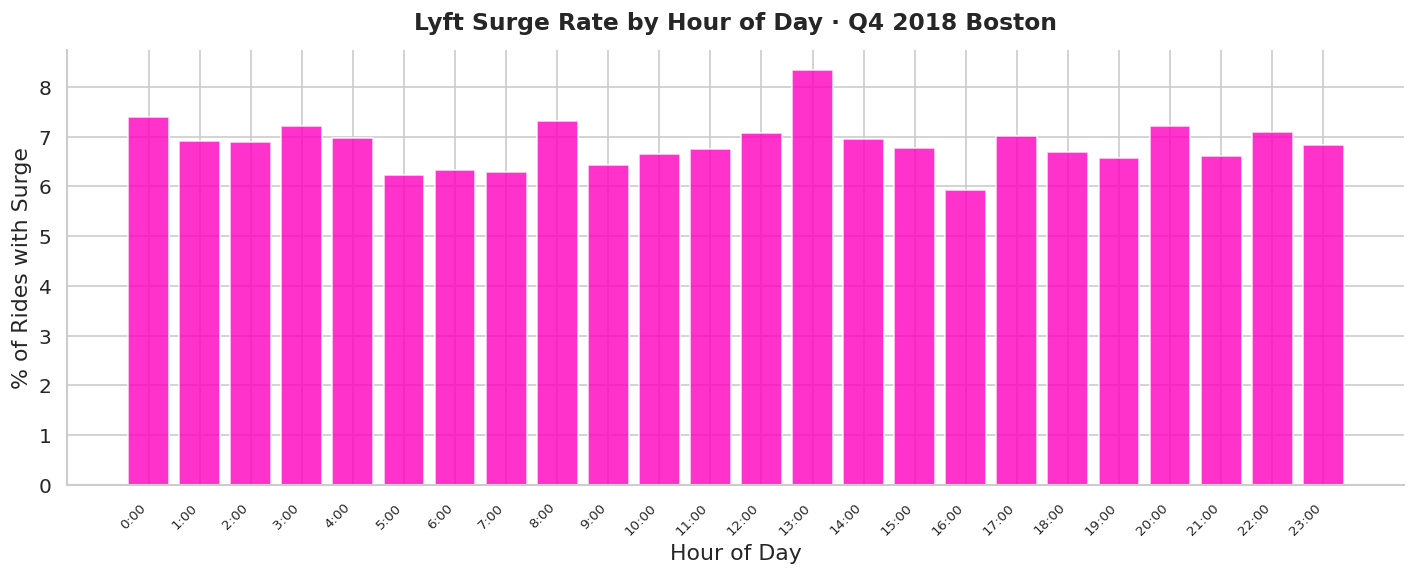


Note: Surge rate is broadly flat across the day (~6-8%), with a mild peak
around 13:00. This contradicts the expected late-night bar-closing spike.
Interpretation: either surge in Boston Q4 2018 was driven by supply constraints
across all hours, or the dataset's hour distribution obscures time-of-day signal.


In [10]:
# Chart C2: Surge rate by hour (Lyft)

surge_hourly = lyft.groupby('hour').apply(
    lambda x: (x['surge_multiplier'] > 1).mean() * 100
).reset_index(name='surge_rate_pct')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(surge_hourly['hour'], surge_hourly['surge_rate_pct'],
       color=LYFT_COLOR, alpha=0.8, edgecolor='white')
ax.set_title('Lyft Surge Rate by Hour of Day · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% of Rides with Surge')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('c2_surge_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Surge rate is broadly flat across the day (~6-8%), with a mild peak")
print("around 13:00. This contradicts the expected late-night bar-closing spike.")
print("Interpretation: either surge in Boston Q4 2018 was driven by supply constraints")
print("across all hours, or the dataset's hour distribution obscures time-of-day signal.")

## Section D: Weather & Demand

> **Question: Does weather affect ride volume or pricing in Boston's Q4?**

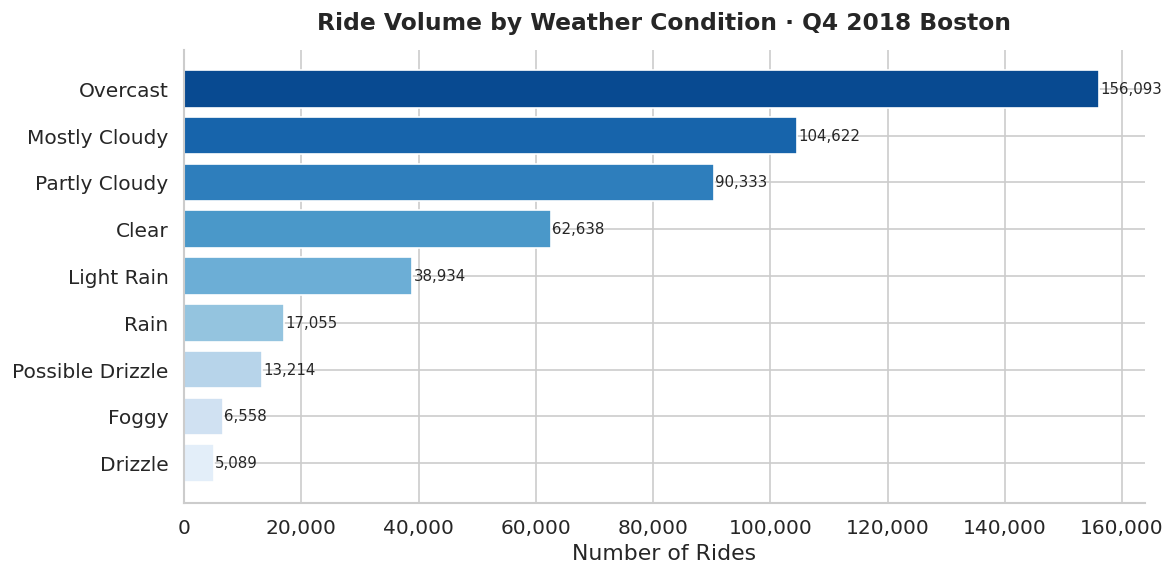


Note: Overcast dominates volume (156K rides), followed by Mostly Cloudy (105K)
and Partly Cloudy (90K). Clear weather ranks 4th (63K). This reflects Boston's
Q4 climate: overcast and cloudy conditions are the norm, not the exception.
Volume distribution mirrors day-frequency of each condition, not demand preference.


In [12]:
# Chart D1: Ride volume by weather condition

weather_vol = df.groupby('weather_summary').size().reset_index(name='rides').sort_values('rides', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_w = sns.color_palette('Blues_r', len(weather_vol))
bars = ax.barh(weather_vol['weather_summary'][::-1], weather_vol['rides'][::-1],
               color=colors_w[::-1])
ax.set_title('Ride Volume by Weather Condition · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Rides')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, weather_vol['rides'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('d1_weather_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Overcast dominates volume (156K rides), followed by Mostly Cloudy (105K)")
print("and Partly Cloudy (90K). Clear weather ranks 4th (63K). This reflects Boston's")
print("Q4 climate: overcast and cloudy conditions are the norm, not the exception.")
print("Volume distribution mirrors day-frequency of each condition, not demand preference.")


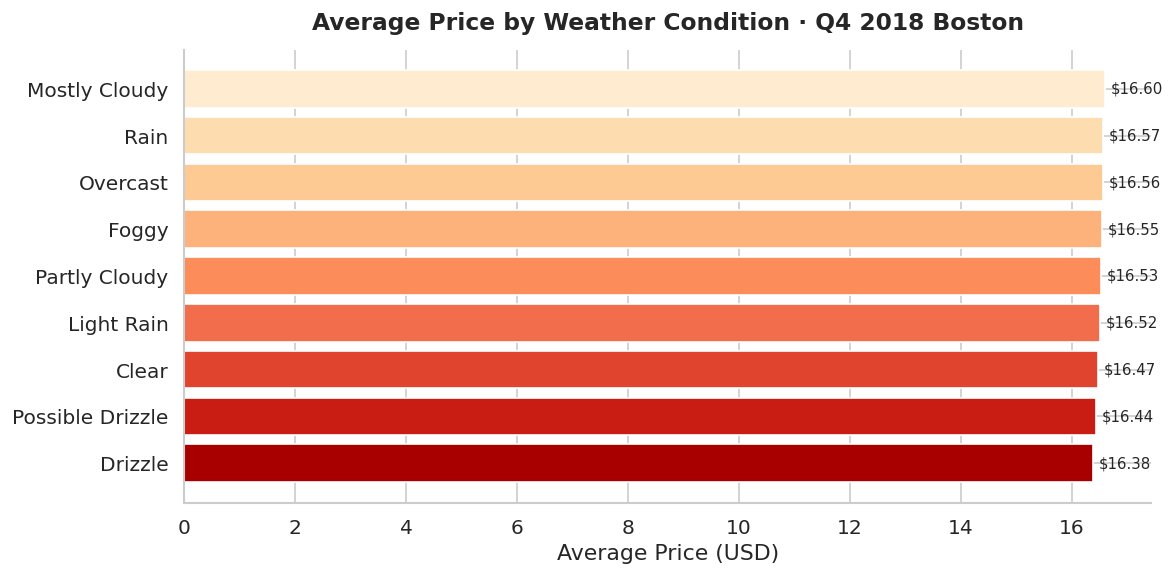


Note: Price differences across weather conditions are negligible, the spread
from highest (Mostly Cloudy $16.60) to lowest (Drizzle $16.38) is only $0.22.
Weather condition has effectively no impact on average pricing in this dataset.
The earlier hypothesis that rain drives higher prices via surge is not supported.


In [15]:
# Chart D2: Avg price by weather condition (priceable rides only)

weather_price = (
    priced.groupby('weather_summary')['price_usd']
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors_w2 = sns.color_palette('OrRd', len(weather_price))
bars = ax.barh(weather_price['weather_summary'][::-1], weather_price['mean'][::-1],
               color=colors_w2[::-1])
ax.set_title('Average Price by Weather Condition · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average Price (USD)')
for bar, val in zip(bars, weather_price['mean'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('d2_weather_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Price differences across weather conditions are negligible, the spread")
print("from highest (Mostly Cloudy $16.60) to lowest (Drizzle $16.38) is only $0.22.")
print("Weather condition has effectively no impact on average pricing in this dataset.")
print("The earlier hypothesis that rain drives higher prices via surge is not supported.")

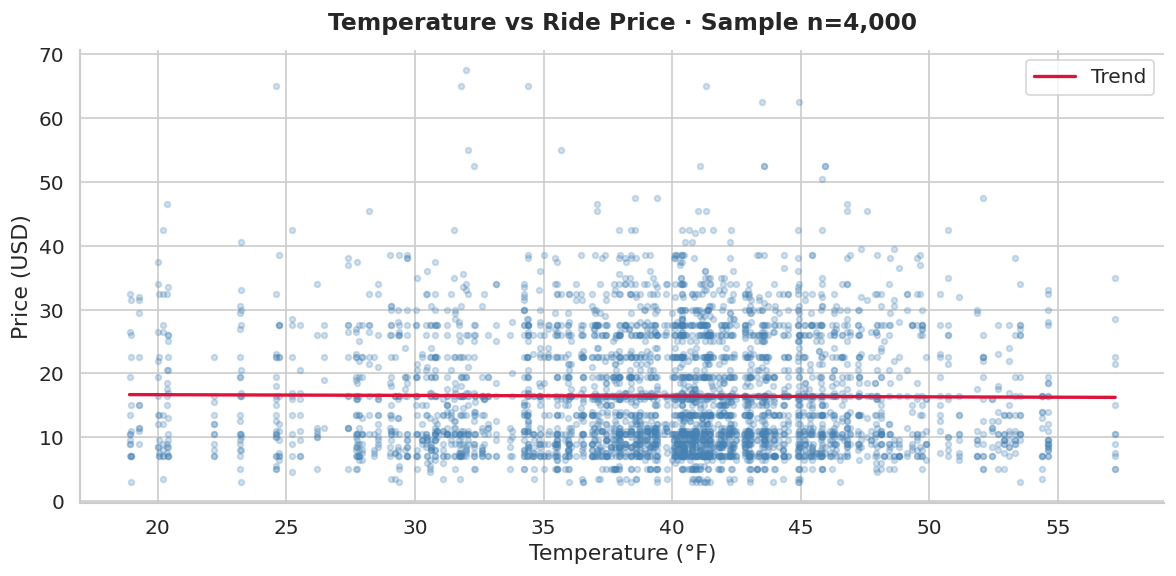


Temperature–Price correlation (Pearson r): -0.001
Temperature has essentially zero linear relationship with price (r = -0.001).
The trend line is flat. Cold weather alone does not drive higher fares in
Boston Q4 2018 at this level of analysis.


In [18]:
# Chart D3: Temperature vs price scatter

sample_w = priced.sample(4000, random_state=99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample_w['temperature_f'], sample_w['price_usd'],
           alpha=0.25, s=12, color='steelblue')

z = np.polyfit(sample_w['temperature_f'].dropna(),
               sample_w.loc[sample_w['temperature_f'].notna(), 'price_usd'], 1)
p = np.poly1d(z)
x_range = np.linspace(sample_w['temperature_f'].min(), sample_w['temperature_f'].max(), 100)
ax.plot(x_range, p(x_range), color='crimson', linewidth=2, label='Trend')

ax.set_title('Temperature vs Ride Price · Sample n=4,000',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('d3_temp_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

temp_price_corr = priced['temperature_f'].corr(priced['price_usd'])
print(f"\nTemperature–Price correlation (Pearson r): {temp_price_corr:.3f}")
print("Temperature has essentially zero linear relationship with price (r = -0.001).")
print("The trend line is flat. Cold weather alone does not drive higher fares in")
print("Boston Q4 2018 at this level of analysis.")

## Section E: Ratings

> **Question: What does rider satisfaction look like across platforms and tiers?**

*Ratings available for ~13.4% of rides (93,000 rows). Present for both platforms.*  
*The 86.6% of rides without ratings limits interpretability; results are descriptive of the rated subset only.*

In [19]:
rated = df[df['has_ratings']].copy()
print(f"Rides with ratings: {len(rated):,}")
print()
print("Platform split in rated subset:")
print(rated['platform'].value_counts())

Rides with ratings: 93,000

Platform split in rated subset:
platform
Uber    51743
Lyft    41257
Name: count, dtype: int64


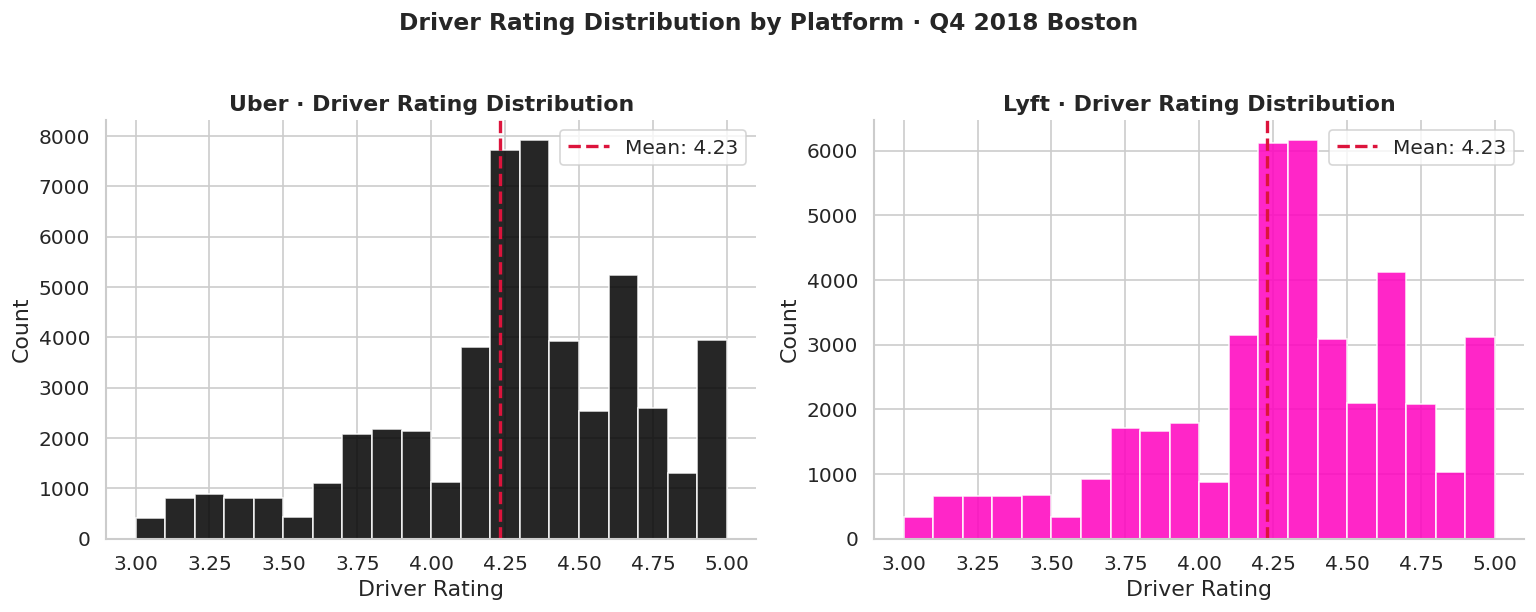

In [20]:
# Chart E1: Driver rating distribution by platform

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, platform in zip(axes, ['Uber', 'Lyft']):
    sub = rated[rated['platform'] == platform]['driver_rating']
    ax.hist(sub, bins=20, color=PALETTE[platform], alpha=0.85, edgecolor='white')
    ax.axvline(sub.mean(), color='crimson', linewidth=2, linestyle='--',
               label=f'Mean: {sub.mean():.2f}')
    ax.set_title(f'{platform} · Driver Rating Distribution', fontweight='bold')
    ax.set_xlabel('Driver Rating')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Driver Rating Distribution by Platform · Q4 2018 Boston',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e1_driver_ratings.png', dpi=150, bbox_inches='tight')
plt.show()


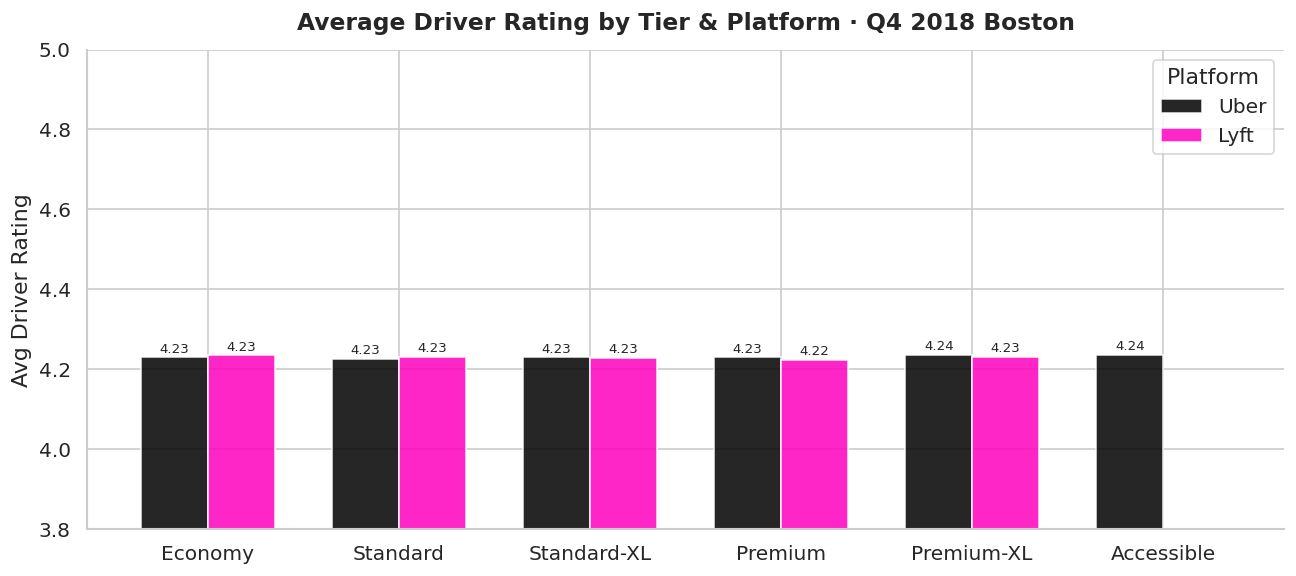


Both platforms: mean driver rating = 4.23 across all tiers.
Variation across tiers is <0.02 points — effectively uniform.


In [21]:
# Chart E2: Avg driver rating by ride tier

tier_ratings = (
    rated[rated['ride_tier'].isin(TIER_ORDER)]
    .groupby(['ride_tier', 'platform'])['driver_rating']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TIER_ORDER))
width = 0.35
for i, platform in enumerate(['Uber', 'Lyft']):
    sub = tier_ratings[tier_ratings['platform'] == platform].set_index('ride_tier')
    vals = [sub.loc[t, 'driver_rating'] if t in sub.index else 0 for t in TIER_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=platform, color=PALETTE[platform], alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average Driver Rating by Tier & Platform · Q4 2018 Boston',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Avg Driver Rating')
ax.set_ylim(3.8, 5.0)
ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER)
ax.legend(title='Platform')
plt.tight_layout()
plt.savefig('e2_ratings_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBoth platforms: mean driver rating = 4.23 across all tiers.")
print("Variation across tiers is <0.02 points — effectively uniform.")

## EDA Summary: Key Findings

### A · Demand Patterns
- Demand is relatively flat across 24 hours with mild peaks around midnight and 23:00; consistent with nightlife and late-commute driven hailing in Boston.
- Both platforms follow nearly identical hourly demand curves, with Uber running ~25% higher volume at every hour. No evidence of platform-specific use cases.
- Top corridors are geographically compact, Financial District ↔ South Station, West End ↔ Fenway — reflecting short urban trips rather than cross-city hauls.

### B · Pricing
- Lyft's overall average ($17.36) exceeds Uber's ($15.78), but this reflects product mix, not tier-for-tier pricing. Uber's Taxi product (no price data) and higher Economy volume pull its average down.
- Price-distance correlation is moderate for both platforms (Lyft r=0.361, Uber r=0.337). Price in ride-hailing is as much a function of tier and surge as raw distance; the scatter plot shows clear horizontal price bands by product tier.
- Premium-XL (Black SUV / Lux Black XL) is the most expensive tier on both platforms, averaging ~$30–32.

### C · Surge Pricing (Lyft Only)
- 6.9% of Lyft rides carry any surge above baseline (1.0). The overwhelming majority (93.1%) ride at flat pricing.
- Surge rate is broadly flat across all hours of the day (~6–8%), with a mild peak around 13:00. The expected late-night bar-closing spike is not present in this data, suggesting supply constraints may be distributed across all hours rather than concentrated at night.
- Uber surge data is not captured at the row level in this dataset.

### D · Weather & Demand
- Overcast is the dominant weather condition by ride volume (156K), followed by Mostly Cloudy and Partly Cloudy. Clear weather ranks 4th, consistent with Boston's Q4 climate where overcast days are the norm.
- Price differences across weather conditions are negligible: the spread from highest (Mostly Cloudy, $16.60) to lowest (Drizzle, $16.38) is $0.22. Weather has no meaningful impact on pricing.
- Temperature shows essentially zero correlation with price (r = -0.001). Cold weather alone does not drive fare increases in this dataset.

### E · Ratings
- Both platforms produce an identical mean driver rating of 4.23, with less than 0.02 points of variation across all six ride tiers. Rating scores are effectively uniform across the board.
- Ratings are available for only 13.4% of rides (93,000 rows out of 494,537). With 86.6% of rides unrated, conclusions from this section are descriptive of the rated subset only and should not be generalized to the full population.
